# Macroeconomic forecasting with neural networks

Selected series: **S&P 500**, **UNRATE**, and **FEDFUNDS**.

The data audit and exploration below are complete for the supplied revised August 2026 FRED-MD vintage. The three neural models are implemented. The full forecasting experiment is controlled by `RUN_EXPERIMENT` near the end of the notebook and is off by default.

**Forecasting Setup**

Train on 6 years of data -> evaluate on next six years -> repeat
- justification -> average business cycle

Train the model on six years of historical data, then evaluate its forecasts on the following six years. Repeat this process by moving the train and evaluation windows forward through time.

The six-year window is chosen to roughly match the length of an average business cycle, so each evaluation period is more likely to include different economic conditions, such as expansion and contraction. This helps measure whether the model performs consistently across changing market regimes rather than only during one short period.

Forecasting Baseline: y_hat<sub>t+1</sub> = y<sub>t</sub>

Train for 6 years of data at a time with a one year lag





**Implementation note:** The six-year rolling-window proposal above is an earlier design idea. The implementation below uses the chronological 70% training / 15% validation / 15% test split in our agreed experimental-design table. The neural models are independent of this split, so a rolling-window extension can reuse them later.

In [1]:
from pathlib import Path
import hashlib
import math
from typing import NamedTuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from torch import Tensor, nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display, Markdown

# Colab: upload the supplied CSV as data.csv or keep its original filename.
data_candidates = [Path("data.csv"), Path("2026-rev-08-MD.csv"),
                   Path("../2026-rev-08-MD.csv")]
DATA_PATH = next((candidate for candidate in data_candidates if candidate.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Upload data.csv or 2026-rev-08-MD.csv before running this cell.")

columns = ["S&P 500", "FEDFUNDS", "UNRATE"]
df = pd.read_csv(DATA_PATH)
metadata_mask = df["sasdate"].astype(str).str.strip().eq("Transform:")
transformation_codes = (df.loc[metadata_mask, columns].iloc[0].astype(int).to_dict()
                        if metadata_mask.any() else {})
# The codes describe suggested transformations; they are not observations.
df = df.loc[~metadata_mask].copy()
extracted = df[["sasdate", *columns]].copy()
extracted["sasdate"] = pd.to_datetime(extracted["sasdate"], format="%m/%d/%Y")
extracted[columns] = extracted[columns].apply(pd.to_numeric, errors="raise")
extracted = extracted.sort_values("sasdate").reset_index(drop=True)

months = pd.PeriodIndex(extracted["sasdate"], freq="M")
expected_months = pd.period_range(months[0], periods=len(months), freq="M")
if not months.equals(expected_months):
    raise ValueError("The data must contain one row per consecutive month.")

# Decision: follow the PDF's 'use the provided series as-is' instruction.
# Model and describe levels; do not apply the metadata's suggested transforms.
# Keep missing rows so that every lag still means exactly one calendar month.
DATA_REPRESENTATION = "supplied levels"
extracted.to_csv("selected_columns.csv", index=False)
print(f"Loaded {len(extracted):,} monthly rows from {DATA_PATH.name}.")
print(f"Period: {months[0]} through {months[-1]}; representation: {DATA_REPRESENTATION}.")

Loaded 811 monthly rows from 2026-rev-08-MD.csv.
Period: 1959-01 through 2026-07; representation: supplied levels.


## 1. Data preparation: verified source and transformation status

**Finding:** The supplied `2026-rev-08-MD.csv` is a file of levels. On September 13, 2026, its bytes matched the [official revised August 2026 FRED-MD download](https://www.stlouisfed.org/-/media/project/frbstl/stlouisfed/research/fred-md/monthly/2026-rev-08-md.csv) exactly. The fingerprint check below shows whether the file loaded in this session is that verified file.

The `Transform:` row contains suggested transformation codes. For these columns, **5 means first difference of the natural logarithm** and **2 means first difference of the level**. Those transformations have not been applied in the CSV. [FRED-MD paper, Appendix, pp. 26-29](https://files.stlouisfed.org/files/htdocs/fred-databases/fredmd.pdf)

**Decision for this homework:** The PDF's statement that the file is already transformed conflicts with the actual data. We follow its explicit instruction to **use the supplied series as-is**, retaining levels after removing the metadata row. This is a documented implementation choice, not confirmation of the instructor's intended representation. If the instructor supplies a different prepared file, rerun the analysis and describe its units accordingly.

The audit below computes hypothetical February 1959 transformed values only to demonstrate the difference; it does not replace the model inputs.

In [2]:
VERIFIED_SOURCE_SHA256 = "412b5451f32321b597c86b95603f5815ae0bd6e44eb7388e4c415156434ac0a4"
source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print("Loaded file matches verified official vintage:", source_sha256 == VERIFIED_SOURCE_SHA256)
print("SHA-256:", source_sha256)

analysis_columns = ["S&P 500", "UNRATE", "FEDFUNDS"]
transformation_labels = {5: "log(x_t) - log(x_t-1)", 2: "x_t - x_t-1"}
audit_rows = []
for column in analysis_columns:
    first, second = extracted[column].iloc[:2]
    tcode = transformation_codes.get(column)
    hypothetical = (np.log(second / first) if tcode == 5
                    else second - first if tcode == 2 else np.nan)
    audit_rows.append({"Series": column, "Metadata code": tcode,
                       "Suggested transformation": transformation_labels.get(tcode, "Not supplied"),
                       "First supplied value": first, "Second supplied value": second,
                       "Second value if transformed": hypothetical})
transformation_audit = pd.DataFrame(audit_rows).set_index("Series")
display(transformation_audit.style.format({"Metadata code": "{:.0f}",
        "First supplied value": "{:.2f}", "Second supplied value": "{:.2f}",
        "Second value if transformed": "{:.5f}"}, na_rep="n.a."))

Loaded file matches verified official vintage: True
SHA-256: 412b5451f32321b597c86b95603f5815ae0bd6e44eb7388e4c415156434ac0a4


,Metadata code,Suggested transformation,First supplied value,Second supplied value,Second value if transformed
Series,,,,,
S&P 500,5,log(x_t) - log(x_t-1),55.62,54.77,-0.01540
UNRATE,2,x_t - x_t-1,6.00,5.90,-0.10000
FEDFUNDS,2,x_t - x_t-1,2.48,2.43,-0.05000


For example, the supplied February 1959 S&P 500 value is **54.77**, while its first log difference would be about **-0.01540**. UNRATE is **5.90**, rather than a change of **-0.10 percentage points**; FEDFUNDS is **2.43**, rather than **-0.05 percentage points**. These comparisons establish that the selected columns contain levels.

There are 811 consecutive calendar months, January 1959-July 2026. Only UNRATE has a missing value, in October 2025. We retain the row, omit the missing value from descriptive calculations, and exclude affected forecasting windows. We do not interpolate or fill it using future data. The full-sample descriptions below are required exploration; they are not used to select hyperparameters or fit normalization statistics. This is an evaluation using one data vintage, not a reconstruction of what was available in real time.

## 2. What the selected variables measure

| Series | FRED-MD group | Units in this notebook | Meaning and basic economic relevance |
|---|---|---|---|
| **S&P 500** | 8: Stock market | Index points | Measures the prices of large U.S. publicly traded companies. It provides a view of equity-market conditions and expectations about companies' prospects. This is a price index; dividends are excluded. |
| **UNRATE** | 2: Labor market | Percent of the labor force; seasonally adjusted | Measures the share of the civilian labor force that is unemployed. It helps describe labor-market slack and the strength of economic activity. |
| **FEDFUNDS** | 6: Interest and exchange rates | Percent; monthly average of daily figures, not seasonally adjusted | Measures the effective overnight federal funds interest rate. It helps describe monetary-policy conditions and the cost of short-term borrowing. |

The three choices satisfy the requirement to use different FRED-MD groups. Definitions and grouping: [FRED-MD Appendix](https://files.stlouisfed.org/files/htdocs/fred-databases/fredmd.pdf), [S&P 500 notes](https://fred.stlouisfed.org/series/SP500), [UNRATE notes](https://fred.stlouisfed.org/series/UNRATE), and [FEDFUNDS notes](https://fred.stlouisfed.org/series/FEDFUNDS). The S&P 500 series used here is the monthly column in the supplied FRED-MD vintage; it is not the daily series downloaded from the separate SP500 page.

A value of 5 in either rate series means **5%**, not 0.05. Rate standard deviations are expressed in **percentage points**; the S&P 500 standard deviation is in **index points**.

## 3. Descriptive statistics and usable observations

Statistics use all nonmissing supplied values before window construction. **N** is the number of usable monthly observations, not the number of supervised forecast examples. Standard deviation uses the sample definition (`ddof=1`). Lag-1 autocorrelation is the correlation between adjacent calendar months; we shift the original series before excluding missing pairs so that September and November 2025 are not incorrectly treated as adjacent.

In [3]:
def describe_series(frame, selected_columns):
    rows = []
    for column in selected_columns:
        series = frame[column].astype(float)
        rows.append({"Series": column, "N": int(series.count()),
                     "Mean": series.mean(), "Median": series.median(),
                     "Std. dev.": series.std(ddof=1), "Minimum": series.min(),
                     "Maximum": series.max(),
                     "Lag-1 autocorrelation": series.corr(series.shift(1))})
    return pd.DataFrame(rows).set_index("Series")


descriptive_stats = describe_series(extracted, analysis_columns)
display(descriptive_stats.style.format({"N": "{:,.0f}", "Mean": "{:,.2f}",
        "Median": "{:,.2f}", "Std. dev.": "{:,.2f}", "Minimum": "{:,.2f}",
        "Maximum": "{:,.2f}", "Lag-1 autocorrelation": "{:.4f}"}))

coverage_rows = []
extrema_rows = []
for column in analysis_columns:
    series = extracted[column]
    coverage_rows.append({"Series": column,
                          "First month": extracted.loc[series.first_valid_index(), "sasdate"].strftime("%Y-%m"),
                          "Last month": extracted.loc[series.last_valid_index(), "sasdate"].strftime("%Y-%m"),
                          "Missing observations": int(series.isna().sum()),
                          "Valid adjacent-month pairs": int((series.notna() & series.shift(1).notna()).sum())})
    extrema_rows.append({"Series": column,
                        "First month at minimum": extracted.loc[series.idxmin(), "sasdate"].strftime("%Y-%m"),
                        "First month at maximum": extracted.loc[series.idxmax(), "sasdate"].strftime("%Y-%m")})
coverage = pd.DataFrame(coverage_rows).set_index("Series")
extreme_dates = pd.DataFrame(extrema_rows).set_index("Series")
display(coverage)
display(extreme_dates)

EDA_OUTPUT = Path("output/data_exploration")
EDA_OUTPUT.mkdir(parents=True, exist_ok=True)
descriptive_stats.to_csv(EDA_OUTPUT / "descriptive_statistics.csv")
coverage.to_csv(EDA_OUTPUT / "data_coverage.csv")

,N,Mean,Median,Std. dev.,Minimum,Maximum,Lag-1 autocorrelation
Series,,,,,,,
S&P 500,811,"1,087.41",418.48,"1,462.46",53.73,"7,481.34",0.9991
UNRATE,810,5.85,5.60,1.68,3.40,14.80,0.9681
FEDFUNDS,811,4.76,4.61,3.58,0.05,19.10,0.9907


,First month,Last month,Missing observations,Valid adjacent-month pairs
Series,,,,
S&P 500,1959-01,2026-07,0,810
UNRATE,1959-01,2026-07,1,808
FEDFUNDS,1959-01,2026-07,0,810


,First month at minimum,First month at maximum
Series,,
S&P 500,1960-10,2026-07
UNRATE,1968-09,2020-04
FEDFUNDS,2020-04,1981-06


## 4. Full-series plots

Each panel shows the entire supplied history on a linear scale in its original units. The vertical axes differ because index points and interest/unemployment rates have different meanings. Missing values are left as gaps. The figure is also saved as a PNG for the report.

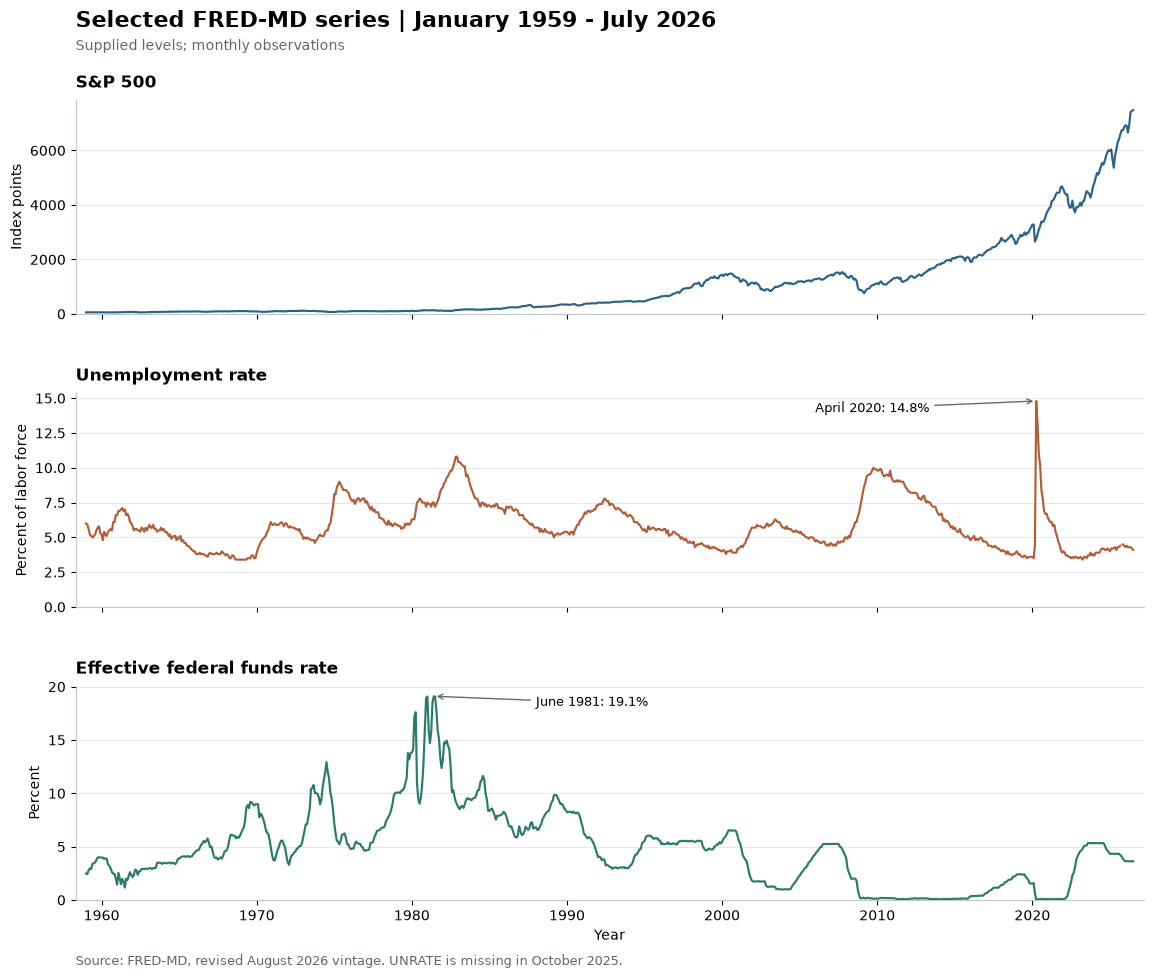

In [4]:
plot_specs = {
    "S&P 500": ("S&P 500", "Index points", "#28628C"),
    "UNRATE": ("Unemployment rate", "Percent of labor force", "#B45C36"),
    "FEDFUNDS": ("Effective federal funds rate", "Percent", "#287B69"),
}
with plt.rc_context({"font.size": 10, "axes.titlesize": 12,
                     "axes.labelsize": 10, "figure.facecolor": "white"}):
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    for ax, column in zip(axes, analysis_columns):
        title, unit, color = plot_specs[column]
        ax.plot(extracted["sasdate"], extracted[column], color=color, linewidth=1.55)
        ax.set_title(title, loc="left", fontweight="bold", pad=9)
        ax.set_ylabel(unit)
        ax.set_ylim(bottom=0)
        ax.grid(axis="y", color="#E0E5EA", linewidth=0.6)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#BFC6CE")
        ax.margins(x=0.01)

    unrate_peak = extracted["UNRATE"].idxmax()
    axes[1].annotate("April 2020: 14.8%", xy=(extracted.loc[unrate_peak, "sasdate"], 14.8),
                     xytext=(pd.Timestamp("2006-01-01"), 14.0),
                     arrowprops={"arrowstyle": "->", "color": "#656B72"}, fontsize=9)
    funds_peak = extracted["FEDFUNDS"].idxmax()
    axes[2].annotate("June 1981: 19.1%", xy=(extracted.loc[funds_peak, "sasdate"], 19.1),
                     xytext=(pd.Timestamp("1988-01-01"), 18.2),
                     arrowprops={"arrowstyle": "->", "color": "#656B72"}, fontsize=9)
    axes[-1].xaxis.set_major_locator(mdates.YearLocator(10))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[-1].set_xlabel("Year")
    start_label = extracted["sasdate"].min().strftime("%B %Y")
    end_label = extracted["sasdate"].max().strftime("%B %Y")
    fig.suptitle(f"Selected FRED-MD series | {start_label} - {end_label}",
                 fontsize=16, fontweight="bold", x=0.09, ha="left", y=0.975)
    fig.text(0.09, 0.935, "Supplied levels; monthly observations", fontsize=10, color="#5E6772")
    fig.text(0.09, 0.02, "Source: FRED-MD, revised August 2026 vintage. UNRATE is missing in October 2025.",
             fontsize=9, color="#5E6772")
    fig.subplots_adjust(top=0.885, bottom=0.085, left=0.09, right=0.98, hspace=0.37)
    fig.savefig(EDA_OUTPUT / "full_series.png", dpi=180, facecolor="white")
    plt.show()
    plt.close(fig)

## 5. Simple interpretation of the data

**S&P 500:** The mean is **1,087.41 index points**, compared with a median of **418.48**, and the standard deviation is **1,462.46 points**. The long-run upward movement and much higher recent levels help explain the large mean-median gap and wide range (**53.73-7,481.34**). Lag-1 autocorrelation is **0.9991**, so neighboring monthly levels are very similar relative to the overall long-run variation. This does not establish that returns are predictable, and the level standard deviation is not a measure of monthly return volatility. The decline from **1,539.66 in October 2007 to 757.13 in March 2009** is a clear unusual period in this vintage, consistent with the equity-market decline during the [financial crisis and Great Recession](https://www.federalreservehistory.org/essays/great-recession-of-200709). These particular endpoints are monthly values from our file.

**UNRATE:** The average is **5.85%**, the median is **5.60%**, and the standard deviation is **1.68 percentage points**. Its **0.9681** lag-1 autocorrelation indicates strong month-to-month persistence. The series moves through sustained rises and declines, with an exceptional **14.80% peak in April 2020**. The [Bureau of Labor Statistics describes the sharp unemployment rise during the COVID-19 disruption](https://www.bls.gov/blog/2021/looking-back-on-the-2020-u-s-labor-market-and-economy.htm). This abrupt change illustrates why a model that follows recent values can still make a large error during an unusual period. October 2025 is missing and is not filled.

**FEDFUNDS:** The mean is **4.76%**, the median is **4.61%**, and the standard deviation is **3.58 percentage points**. Its range, **0.05%-19.10%**, shows very different interest-rate environments across the sample. Lag-1 autocorrelation is **0.9907**, consistent with nearby months often having similar rates. The **June 1981 peak** occurred during the Federal Reserve's effort to reduce high inflation under Paul Volcker. [Federal Reserve History: The Great Inflation](https://www.federalreservehistory.org/essays/great-inflation) The long stretches near zero and periods of rapid rate movement visible in the plot suggest that one full-sample mean cannot describe every period equally well.

**Implication for the experiment:** All three level series are highly persistent, giving the persistence baseline a reasonable justification. Persistence and an upward trend do not establish stationarity or guarantee forecast accuracy. Compare forecast errors within each series because their units differ. The fixed model settings remain the ones chosen before this exploration; full-sample statistics are descriptive and are never used for RevIN or training decisions.

## Reversible Instance Normalization

Each neural model uses statistics from its historical input window to normalize the input, forecast, and reverse normalization before computing loss or evaluation metrics. The future target never contributes to normalization statistics.

We use `scale = sqrt(variance + 1e-5)` and reverse normalization with the same scale. This is the non-affine RevIN variant, without optional learned scale/offset parameters. The model outputs are **index levels for S&P 500 and percentage levels for UNRATE/FEDFUNDS**, as established in the data audit. Do not normalize the input arrays again or manually denormalize model predictions.

Monthly rows are preserved, and forecasting windows containing a missing input or target are excluded. RevIN's reversible scaling is separate from FRED-MD's suggested differencing/log-differencing transformations.

In [5]:
p = 12
MODEL_CONFIG = dict(lags=p, hidden_dim=32, num_layers=1, dropout=0.0)
TRAINING_CONFIG = dict(learning_rate=0.001, batch_size=32,
                       max_epochs=200, patience=20)
SEEDS = (1, 2, 3, 4, 5)

| Choice | What it means | Suggested setting and basic justification |
|---|---|---|
| Number of lags | How many past months the model sees. | **12 months.** One year provides recent history while keeping the input small. |
| Train/validation/test split | Which data train the model, guide training decisions, and measure final performance. | **First 70% / next 15% / final 15%, chronologically.** This gives the model plenty of training data and evaluates its ability to predict later observations. Use common date boundaries across all three series. |
| Hidden dimension | How many internal features the model can learn. | **32 units.** This allows the model to learn useful patterns while keeping it small for a monthly dataset. |
| Number of layers | How many processing layers the model uses. | **One hidden layer for the fully connected model; one LSTM layer for both LSTM models.** Simple architectures make the models easier to train and compare. |
| Activation function | The function that allows the model to learn nonlinear relationships. | **ReLU for the fully connected hidden layer; standard sigmoid/tanh inside the LSTM.** Use a linear output layer so forecasts can take any numerical value. |
| Optimizer | The method used to update the model’s weights. | **Adam.** It adjusts updates separately for different weights and is a straightforward starting choice. |
| Learning rate | How large the weight updates are during training. | **0.001, held constant.** This is Adam’s default learning rate in PyTorch and provides a reasonable starting point. |
| Batch size | How many training examples are processed before each weight update. | **32 input windows.** This provides several examples per update while allowing multiple updates per training epoch. |
| Dropout | Randomly disabling some internal units during training to discourage overfitting. | **0: no dropout.** Small networks and early stopping keep the design simple while helping limit overfitting. |
| Stopping criterion | When to stop training. | **Maximum of 200 epochs, stopping after 20 epochs without improved validation MSE.** Restore the weights from the best validation epoch to avoid keeping a model that has begun to overfit. |
| Evaluation metrics | How forecast accuracy is measured. | **RMSE and MAE.** RMSE emphasizes large mistakes, while MAE measures average absolute error and is less sensitive to extreme errors. Lower values are better. |

In [6]:
def make_windows(series, p):
    """Return finite (past p months, next month) examples, in time order."""
    series = np.asarray(series, dtype=np.float32)
    if series.ndim != 1 or not isinstance(p, int) or p < 1:
        raise ValueError("Use a one-dimensional series and a positive integer p.")
    X, y = [], []
    for i in range(p, len(series)):
        window = series[i-p:i]
        target = series[i]
        if np.isfinite(window).all() and np.isfinite(target):
            X.append(window)
            y.append(target)
    return np.asarray(X, dtype=np.float32).reshape(-1, p), np.asarray(y, dtype=np.float32)

In [7]:
def prepare_datasets(df, column_name, p):
    """Split by target month, keeping the original calendar boundaries.

    Validation/test inputs can use earlier observed history. Invalid windows
    are excluded after boundaries are fixed; no future-value imputation is used.
    All models and the baseline for a column use the same retained examples.
    """
    series = df[column_name].to_numpy(dtype=np.float32)
    if not isinstance(p, int) or p < 1 or len(series) <= p:
        raise ValueError("p must be positive and smaller than the series length.")
    train_end = int(0.7 * len(series))
    val_end = train_end + int(0.15 * len(series))
    splits = {name: ([], []) for name in ("train", "val", "test")}

    for i in range(p, len(series)):
        window, target = series[i-p:i], series[i]
        if not (np.isfinite(window).all() and np.isfinite(target)):
            continue
        name = "train" if i < train_end else "val" if i < val_end else "test"
        splits[name][0].append(window)
        splits[name][1].append(target)

    result = []
    for name in ("train", "val", "test"):
        X, y = splits[name]
        if not X:
            raise ValueError(f"No usable {name} examples for {column_name}.")
        result.extend((np.asarray(X, dtype=np.float32).reshape(-1, p),
                       np.asarray(y, dtype=np.float32)))
    return tuple(result)

In [8]:
class WindowStatistics(NamedTuple):
    mean: Tensor
    scale: Tensor


class RevIN(nn.Module):
    """Window normalization and its inverse, without learnable affine terms.

    Statistics are per example, across time only. Passing them explicitly
    prevents one forward call from overwriting another window's statistics.
    This is the simple non-affine RevIN variant; the homework does not require
    the optional learnable affine transformation.
    """

    def __init__(self, eps: float = 1e-5):
        super().__init__()
        if not math.isfinite(eps) or eps <= 0:
            raise ValueError("eps must be finite and positive.")
        self.eps = eps

    def normalize(self, x: Tensor) -> tuple[Tensor, WindowStatistics]:
        if x.ndim != 3 or x.shape[1] == 0 or x.shape[2] != 1:
            raise ValueError("Expected input shape (batch, lags, 1).")
        if not x.is_floating_point():
            raise TypeError("Inputs must be floating-point tensors.")
        mean = x.mean(dim=1, keepdim=True).detach()
        scale = (x.var(dim=1, keepdim=True, unbiased=False) + self.eps).sqrt().detach()
        return (x - mean) / scale, WindowStatistics(mean, scale)

    def denormalize(self, x: Tensor, stats: WindowStatistics) -> Tensor:
        """Restore a normalized window or forecast of shape (batch, time, 1)."""
        return x * stats.scale + stats.mean

In [9]:
class _Forecaster(nn.Module):
    def __init__(self, lags: int, hidden_dim: int, num_layers: int,
                 dropout: float, eps: float):
        super().__init__()
        for name, value in (("lags", lags), ("hidden_dim", hidden_dim),
                            ("num_layers", num_layers)):
            if isinstance(value, bool) or not isinstance(value, int) or value < 1:
                raise ValueError(f"{name} must be a positive integer.")
        if not 0 <= dropout < 1:
            raise ValueError("dropout must be in [0, 1).")
        self.lags = lags
        self.revin = RevIN(eps)

    def _normalize(self, x: Tensor) -> tuple[Tensor, WindowStatistics]:
        if x.ndim != 3 or x.shape[1:] != (self.lags, 1):
            raise ValueError(f"Expected input shape (batch, {self.lags}, 1).")
        return self.revin.normalize(x)

    def _restore(self, prediction: Tensor, stats: WindowStatistics) -> Tensor:
        # Keep the batch dimension even when the batch contains one example.
        return self.revin.denormalize(prediction.unsqueeze(1), stats).squeeze(1)

In [10]:
def persistence_predict(X):
    return X[:, -1]

In [11]:
def _metric_arrays(y_true, y_pred):
    actual = np.asarray(y_true).reshape(-1)
    predicted = np.asarray(y_pred).reshape(-1)
    if actual.size == 0 or actual.shape != predicted.shape:
        raise ValueError("Actual values and predictions must have equal, nonzero lengths.")
    return actual, predicted


def mae(y_true, y_pred):
    actual, predicted = _metric_arrays(y_true, y_pred)
    return np.mean(np.abs(actual - predicted))


def rmse(y_true, y_pred):
    actual, predicted = _metric_arrays(y_true, y_pred)
    return np.sqrt(np.mean((actual - predicted) ** 2))

In [12]:
sample_rows = []
train_end = int(0.7 * len(extracted))
val_end = train_end + int(0.15 * len(extracted))
for column_name in columns:
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_datasets(extracted, column_name, p)
    sample_rows.append({"Series": column_name, "Training windows": len(y_train),
                        "Validation windows": len(y_val), "Test windows": len(y_test),
                        "Total usable windows": len(y_train) + len(y_val) + len(y_test)})
forecast_sample_counts = pd.DataFrame(sample_rows).set_index("Series")
display(forecast_sample_counts)
for name, start, end in (("Training", p, train_end), ("Validation", train_end, val_end),
                         ("Test", val_end, len(extracted))):
    first = extracted["sasdate"].iloc[start].strftime("%Y-%m")
    last = extracted["sasdate"].iloc[end-1].strftime("%Y-%m")
    print(f"{name} target-date range: {first} through {last}")
print("UNRATE loses 10 windows to the missing October 2025 observation within this sample.")

,Training windows,Validation windows,Test windows,Total usable windows
Series,,,,
S&P 500,555,121,123,799
FEDFUNDS,555,121,123,799
UNRATE,555,121,113,789


Training target-date range: 1960-01 through 2006-03
Validation target-date range: 2006-04 through 2016-04
Test target-date range: 2016-05 through 2026-07
UNRATE loses 10 windows to the missing October 2025 observation within this sample.


In [13]:

columns = ["S&P 500", "FEDFUNDS", "UNRATE"]

for column_name in columns:
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_datasets(
        extracted,
        column_name,
        p
    )

    # Persistence predictions
    val_predictions = persistence_predict(X_val)
    test_predictions = persistence_predict(X_test)

    print("\n==============================")
    print(column_name)
    print("==============================")

    print("Validation MAE:", mae(y_val, val_predictions))
    print("Validation RMSE:", rmse(y_val, val_predictions))

    print("Test MAE:", mae(y_test, test_predictions))
    print("Test RMSE:", rmse(y_test, test_predictions))


S&P 500
Validation MAE: 39.744293
Validation RMSE: 52.524044
Test MAE: 108.73139
Test RMSE: 148.97289

FEDFUNDS
Validation MAE: 0.059834715
Validation RMSE: 0.15467909
Test MAE: 0.09463414
Test RMSE: 0.18572207

UNRATE
Validation MAE: 0.14049588
Validation RMSE: 0.188951
Test MAE: 0.2699115
Test RMSE: 1.0459784


## Neural forecasting models

The three models below are interchangeable: each takes a float tensor shaped `(batch, p, 1)` and returns `(batch, 1)`. Each model uses its own RevIN and a linear output head. Create a fresh model for each column and seed. The definitions are included in this notebook; no local package imports are needed in Colab.

### FCNN

Flatten the lag window, apply one ReLU hidden layer, and predict one value. The default architecture is **12 inputs -> 32 hidden units -> 1 output**, following the basic structure of Model 3 in the assigned paper.

In [14]:
class FCNN(_Forecaster):
    """Flattened lag window -> ReLU hidden layer(s) -> linear forecast.

    The default single hidden layer follows Model 3 of Almosova and Andresen.
    num_layers counts hidden layers, excluding the scalar output layer.
    """

    def __init__(self, lags: int = 12, hidden_dim: int = 32,
                 num_layers: int = 1, dropout: float = 0.0, eps: float = 1e-5):
        super().__init__(lags, hidden_dim, num_layers, dropout, eps)
        layers = [nn.Flatten(start_dim=1)]
        input_dim = lags
        for _ in range(num_layers):
            layers.extend([nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                           nn.Dropout(dropout)])
            input_dim = hidden_dim
        layers.append(nn.Linear(hidden_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        normalized, stats = self._normalize(x)
        return self._restore(self.network(normalized), stats)

### LSTM

Use `torch.nn.LSTM` to read the window from oldest to newest. A linear head uses the final hidden state. Hidden state resets for each input window.

In [15]:
class LSTM(_Forecaster):
    """Unidirectional torch.nn.LSTM with a linear final-state prediction head."""

    def __init__(self, lags: int = 12, hidden_dim: int = 32,
                 num_layers: int = 1, dropout: float = 0.0, eps: float = 1e-5):
        super().__init__(lags, hidden_dim, num_layers, dropout, eps)
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=False,
            # PyTorch's internal dropout only applies between stacked layers.
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_dim, 1))

    def _encode(self, x: Tensor) -> tuple[Tensor, WindowStatistics]:
        normalized, stats = self._normalize(x)
        # No hidden state is passed in: each input window starts independently.
        hidden_states, _ = self.lstm(normalized)
        return hidden_states, stats

    def forward(self, x: Tensor) -> Tensor:
        hidden_states, stats = self._encode(x)
        return self._restore(self.head(hidden_states[:, -1, :]), stats)

### LSTM with attention

Use the final hidden state as query and every hidden state as both key and value, exactly as specified in the assignment:

$$q=h_p,\quad k_t=v_t=h_t,\quad s_t=\frac{q^\top k_t}{\sqrt{d}},\quad \alpha_t=\operatorname{softmax}(s)_t,\quad c=\sum_t\alpha_t h_t.$$

A linear head predicts from context vector $c$. `forward_with_attention` also returns the weights for interpretation: the first weight is lag 12 and the last is lag 1.

In [16]:
class ScaledDotProductAttention(nn.Module):
    """Use the last hidden state as query and all hidden states as keys/values."""

    def forward(self, hidden_states: Tensor) -> tuple[Tensor, Tensor]:
        # hidden_states: (batch, lags, hidden_dim)
        query = hidden_states[:, -1, :]
        scores = torch.bmm(hidden_states, query.unsqueeze(-1)).squeeze(-1)
        scores = scores / math.sqrt(hidden_states.shape[-1])
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), hidden_states).squeeze(1)
        return context, weights


class LSTMWithAttention(LSTM):
    """Same LSTM backbone, with the homework's attention-weighted context head.

    forward(x) returns forecasts like the other models. For interpretation,
    forward_with_attention(x) also returns (batch, lags) attention weights.
    Weight index 0 is the oldest input (lag p); index -1 is the newest (lag 1).
    """

    def __init__(self, lags: int = 12, hidden_dim: int = 32,
                 num_layers: int = 1, dropout: float = 0.0, eps: float = 1e-5):
        super().__init__(lags, hidden_dim, num_layers, dropout, eps)
        self.attention = ScaledDotProductAttention()

    def forward_with_attention(self, x: Tensor) -> tuple[Tensor, Tensor]:
        hidden_states, stats = self._encode(x)
        context, weights = self.attention(hidden_states)
        return self._restore(self.head(context), stats), weights

    def forward(self, x: Tensor) -> Tensor:
        prediction, _ = self.forward_with_attention(x)
        return prediction

### Connect the models to the existing NumPy datasets

`prepare_datasets` returns inputs shaped `(N, p)` and targets shaped `(N,)`. These helpers add the dimensions PyTorch expects. `predict_model` converts predictions back to `(N,)` for the existing MAE/RMSE functions. Pass the raw prepared windows; RevIN is internal to each model.

In [17]:
MODEL_CLASSES = {"FCNN": FCNN, "LSTM": LSTM,
                 "LSTM with attention": LSTMWithAttention}


def create_model(model_name, seed=1):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    return MODEL_CLASSES[model_name](**MODEL_CONFIG)


def input_tensor(X):
    X = torch.as_tensor(X, dtype=torch.float32)
    if X.ndim != 2 or X.shape[0] == 0 or X.shape[1] != p:
        raise ValueError(f"Expected nonempty inputs of shape (N, {p}).")
    if not torch.isfinite(X).all():
        raise ValueError("Inputs must be finite.")
    return X.unsqueeze(-1)


def target_tensor(y, n):
    y = torch.as_tensor(y, dtype=torch.float32).reshape(-1, 1)
    if y.shape[0] != n or not torch.isfinite(y).all():
        raise ValueError("Targets must be finite and match the input count.")
    return y


def predict_model(model, X, batch_size=256):
    device = next(model.parameters()).device
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in input_tensor(X).split(batch_size):
            predictions.append(model(batch.to(device)).cpu())
    return torch.cat(predictions).numpy().reshape(-1)

### Shared training function

All models use Adam at 0.001, batch size 32, supplied-scale MSE, at most 200 epochs, and patience 20. We restore the checkpoint with the lowest validation MSE. This function takes only training and validation arrays; test data cannot influence early stopping.

Shuffling is limited to complete windows within the training partition. The order inside each window and the chronological split are preserved.

In [18]:
def fit_model(model, X_train, y_train, X_val, y_val, *,
              learning_rate=0.001, batch_size=32, max_epochs=200,
              patience=20, seed=1, device="cpu"):
    if min(batch_size, max_epochs, patience) < 1 or learning_rate <= 0:
        raise ValueError("Training settings must be positive.")
    torch.manual_seed(seed)
    model.to(device)
    train_x = input_tensor(X_train)
    train_y = target_tensor(y_train, len(train_x))
    val_x = input_tensor(X_val).to(device)
    val_y = target_tensor(y_val, len(val_x)).to(device)
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(TensorDataset(train_x, train_y), batch_size=batch_size,
                        shuffle=True, generator=generator)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    history = []
    best_loss = float("inf")
    best_state = None
    best_epoch = 0
    stale_epochs = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss = 0.0
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            if not torch.isfinite(loss):
                raise RuntimeError("Training loss became non-finite.")
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(batch_x)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(val_x), val_y).item()
        if not math.isfinite(val_loss):
            raise RuntimeError("Validation loss became non-finite.")
        history.append({"epoch": epoch,
                        "train_mse": total_loss / len(train_x),
                        "val_mse": val_loss})
        if val_loss < best_loss:
            best_loss, best_epoch = val_loss, epoch
            best_state = {name: value.detach().cpu().clone()
                          for name, value in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    return {"history": pd.DataFrame(history), "best_epoch": best_epoch,
            "best_val_mse": best_loss}

### Verify integration with every selected column

This cell checks shapes, normalization, attention, and gradients using a small training batch from each real series. These are implementation checks with untrained models, not forecasting results.

In [19]:
for column_name in columns:
    X_train, y_train, *_ = prepare_datasets(extracted, column_name, p)
    batch_x = input_tensor(X_train[:4])
    batch_y = target_tensor(y_train[:4], len(batch_x))
    for model_name in MODEL_CLASSES:
        check_model = create_model(model_name)
        prediction = check_model(batch_x)
        assert prediction.shape == batch_y.shape
        assert torch.isfinite(prediction).all()
        nn.functional.mse_loss(prediction, batch_y).backward()
        assert all(parameter.grad is not None and torch.isfinite(parameter.grad).all()
                   for parameter in check_model.parameters())
        normalized, stats = check_model.revin.normalize(batch_x)
        torch.testing.assert_close(check_model.revin.denormalize(normalized, stats), batch_x)
        if model_name == "LSTM with attention":
            _, weights = check_model.forward_with_attention(batch_x)
            torch.testing.assert_close(weights.sum(dim=1), torch.ones(len(batch_x)))
    print(f"{column_name}: all three models passed integration checks.")

S&P 500: all three models passed integration checks.
FEDFUNDS: all three models passed integration checks.
UNRATE: all three models passed integration checks.


### Fit and compare the final configurations

Set `RUN_EXPERIMENT = True` to train all three architectures for all three columns across seeds 1-5 (45 fits). It is off by default so running the notebook to review the implementation does not launch the full experiment.

The test set is evaluated only after selecting each run's checkpoint on validation data. Report mean and standard deviation of MAE/RMSE across seeds within each series. The baseline and neural models use the same retained test windows. A missing UNRATE observation excludes affected UNRATE windows; other columns retain their valid observations.

`trained_models[(column_name, model_name, seed)]` stores each fitted model for later forecast and attention plots. The earlier six-year rolling proposal is not implemented here.

In [20]:
RUN_EXPERIMENT = False

if RUN_EXPERIMENT:
    results = []
    trained_models = {}
    training_histories = {}
    test_forecasts = {}
    for column_name in columns:
        X_train, y_train, X_val, y_val, X_test, y_test = prepare_datasets(
            extracted, column_name, p)
        baseline = persistence_predict(X_test)
        # Repeat the deterministic baseline per seed for the same summary format.
        for seed in SEEDS:
            results.append({"column": column_name, "model": "Persistence",
                            "seed": seed, "mae": mae(y_test, baseline),
                            "rmse": rmse(y_test, baseline)})
        for model_name in MODEL_CLASSES:
            for seed in SEEDS:
                model = create_model(model_name, seed=seed)
                training = fit_model(model, X_train, y_train, X_val, y_val,
                                     seed=seed, **TRAINING_CONFIG)
                predictions = predict_model(model, X_test)
                key = (column_name, model_name, seed)
                trained_models[key] = model
                training_histories[key] = training
                test_forecasts[key] = predictions
                results.append({"column": column_name, "model": model_name,
                                "seed": seed, "mae": mae(y_test, predictions),
                                "rmse": rmse(y_test, predictions)})
                print(f"Finished {column_name} / {model_name} / seed {seed}; "
                      f"best validation epoch: {training['best_epoch']}")

    results = pd.DataFrame(results)
    summary = results.groupby(["column", "model"])[["mae", "rmse"]].agg(["mean", "std"])
    display(summary)
else:
    print("Models are ready. Set RUN_EXPERIMENT = True to run the full comparison.")

Models are ready. Set RUN_EXPERIMENT = True to run the full comparison.


### Inspect trained attention weights

After the experiment, this cell displays weights for three test examples. Column labels are lag numbers, from oldest to newest. The weights describe the model's allocation of attention, not causal effects.

In [21]:
if RUN_EXPERIMENT:
    attention_column = "UNRATE"  # Change to any selected column.
    attention_seed = SEEDS[0]
    attention_model = trained_models[(attention_column, "LSTM with attention", attention_seed)]
    *_, X_test, y_test = prepare_datasets(extracted, attention_column, p)
    example_indices = [0, len(X_test) // 2, len(X_test) - 1]
    attention_model.eval()
    with torch.no_grad():
        forecasts, attention_weights = attention_model.forward_with_attention(
            input_tensor(X_test[example_indices]).to(next(attention_model.parameters()).device))
    display(pd.DataFrame(attention_weights.cpu().numpy(),
                         index=example_indices,
                         columns=[f"lag_{lag}" for lag in range(p, 0, -1)]))

### Implementation references

- Local assignment: **HW1_Part2.pdf**, sections 3-5.
- [Almosova and Andresen, Model 3, section 2.1](https://www.ecb.europa.eu/press/conferences/shared/pdf/20190923_inflation_conference/L2_Almosova.pdf).
- [Kim et al. (2022), RevIN authors' implementation](https://github.com/ts-kim/RevIN).
- [Dive into Deep Learning: Attention Scoring Functions](https://d2l.ai/chapter_attention-mechanisms-and-transformers/attention-scoring-functions.html).
- [PyTorch LSTM documentation](https://docs.pytorch.org/docs/2.14/generated/torch.nn.LSTM.html).